# Homogeneous OPT / FD Benchmark

Small 200x200 benchmarks for acoustic and elastic propagation. Acoustic compares OPT against an explicit FD5 baseline. Elastic compares OPT and a homogeneous collocated FD baseline mostly through Gaussian initial data, so the source-definition mismatch does not dominate.

## 1. Setup

In [1]:
using Pkg
cd(@__DIR__)
Pkg.activate("../")

try
    using Metal
catch err
    @warn "Metal not loaded; continuing on CPU" err
end

using LinearAlgebra
using Statistics
using SparseArrays
using CairoMakie
CairoMakie.activate!()

ParamFile = "../config/testparam.csv"
include("../src/batchFiles/batchGPU.jl")
include("../src/commonBatchs.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")
using .commonBatchs, .planet1D, .GeoPoints

include("../src/flexOPT.jl")
using .flexOPT

include("temporaryHelpers.jl")


  Activating 

devs = Metal.devices() = Metal.MTL.MTLDeviceInstance[Metal.MTL.MTLDeviceInstance (object of type AGXG13XDevice)]

project at `~/Documents/Github/flexOPT`



→ Using Metal backend (1 device(s))
Selected backend type: MetalBackend


downsample_center_crop (generic function with 1 method)

## 2. Shared Grid And Source

In [2]:
shape = (200, 200)
sourcePoint = CartesianIndex(cld(shape[1], 2), cld(shape[2], 2))
store_every = 4
Nt = 160

# Use a small physical grid spacing to keep dx/dt scales moderate and make high f0 visible.
dx = 50.0

# Acoustic background
v0 = 2600.0
velocity_homo = fill(v0, shape)
cfl_acoustic = 0.35
dt_acoustic = cfl_acoustic * dx / (sqrt(2) * v0)
delta_acoustic = (dx, dx, dt_acoustic)

# High-ish f0, still below spatial/time Nyquist diagnostics.
cfl_info_ac = cfl_diagnostics(velocity_homo, delta_acoustic; cfl_safety=cfl_acoustic, ppw=6, samples_per_period=10)
source_f0_acoustic = 0.75 * min(v0 / (6dx), 1 / (10dt_acoustic))
source_t0_acoustic = min(6 / source_f0_acoustic, 0.25Nt * dt_acoustic)
source_amplitude_acoustic = 1.0

@show shape sourcePoint Nt store_every
@show delta_acoustic cfl_info_ac source_f0_acoustic source_t0_acoustic


shape = (200, 200)
sourcePoint = CartesianIndex(100, 100)
Nt = 160
store_every = 4
delta_acoustic = (50.0, 50.0, 0.004759372565678685)
cfl_info_ac = (vmax = 2600.0, vmed = 2600.0, dxmin = 50.0, current_dt = 0.004759372565678685, suggested_dt_2D = 0.004759372565678685, suggested_f0 = 8.666666666666666, suggested_dt_from_f0 = 0.011538461538461539)
source_f0_acoustic = 6.5
source_t0_acoustic = 0.1903749026271474


0.1903749026271474

## 3. Acoustic: FD5 Baseline

In [3]:
preparedFD5_ac = prepare_fd2d_acoustic_fd5_baseline(velocity_homo, delta_acoustic)
timeSignal_ac_fd = source_time_samples(Nt, dt_acoustic, preparedFD5_ac.timePointsUsedForOneStep; t0=source_t0_acoustic, f0=source_f0_acoustic)
sourceFD5_ac = point_source_full(preparedFD5_ac, sourcePoint, timeSignal_ac_fd; amplitude=source_amplitude_acoustic)

source_peak_index_ac = argmax(abs.(timeSignal_ac_fd))
source_peak_time_ac = (source_peak_index_ac - 1) * dt_acoustic
@show maximum(abs, timeSignal_ac_fd) source_peak_index_ac source_peak_time_ac maximum(abs, sourceFD5_ac)

t_fd5_ac = @elapsed frames_fd5_ac_full = propagate_linear_frames_with_source(
    preparedFD5_ac,
    Nt;
    sourceFull=sourceFD5_ac,
    store_every=store_every,
    blowup_limit=1e12,
)
frames_fd5_ac = component_frames(frames_fd5_ac_full, 1)
report_fd5_ac = wavefield_snapshot_report(frames_fd5_ac)
drift_fd5_ac = drift_report(frames_fd5_ac, sourcePoint)
@show t_fd5_ac length(frames_fd5_ac) report_fd5_ac[1] report_fd5_ac[end] drift_fd5_ac[end]


maximum(abs, timeSignal_ac_fd) = 1.0
source_peak_index_ac = 41
source_peak_time_ac = 0.1903749026271474
maximum(abs, sourceFD5_ac) = 1.0
t_fd5_ac = 1.600175
length(frames_fd5_ac) = 41
report_fd5_ac[1] = (frame = 1, nbad = 0, finite_max = 0.0, minimum = 0.0, maximum = 0.0)
report_fd5_ac[end] = (frame = 41, nbad = 0, finite_max = 1.552051740124555e-5, minimum = -8.756446916969838e-6, maximum = 1.552051740124555e-5)
drift_fd5_ac[end] = (frame = 41, cm_x = 99.99999999999982, cm_z = 100.00000000000007, drift_x = -1.8474111129762605e-13, drift_z = 7.105427357601002e-14, maxabs = 1.552051740124555e-5)


(frame = 41, cm_x = 99.99999999999982, cm_z = 100.00000000000007, drift_x = -1.8474111129762605e-13, drift_z = 7.105427357601002e-14, maxabs = 1.552051740124555e-5)

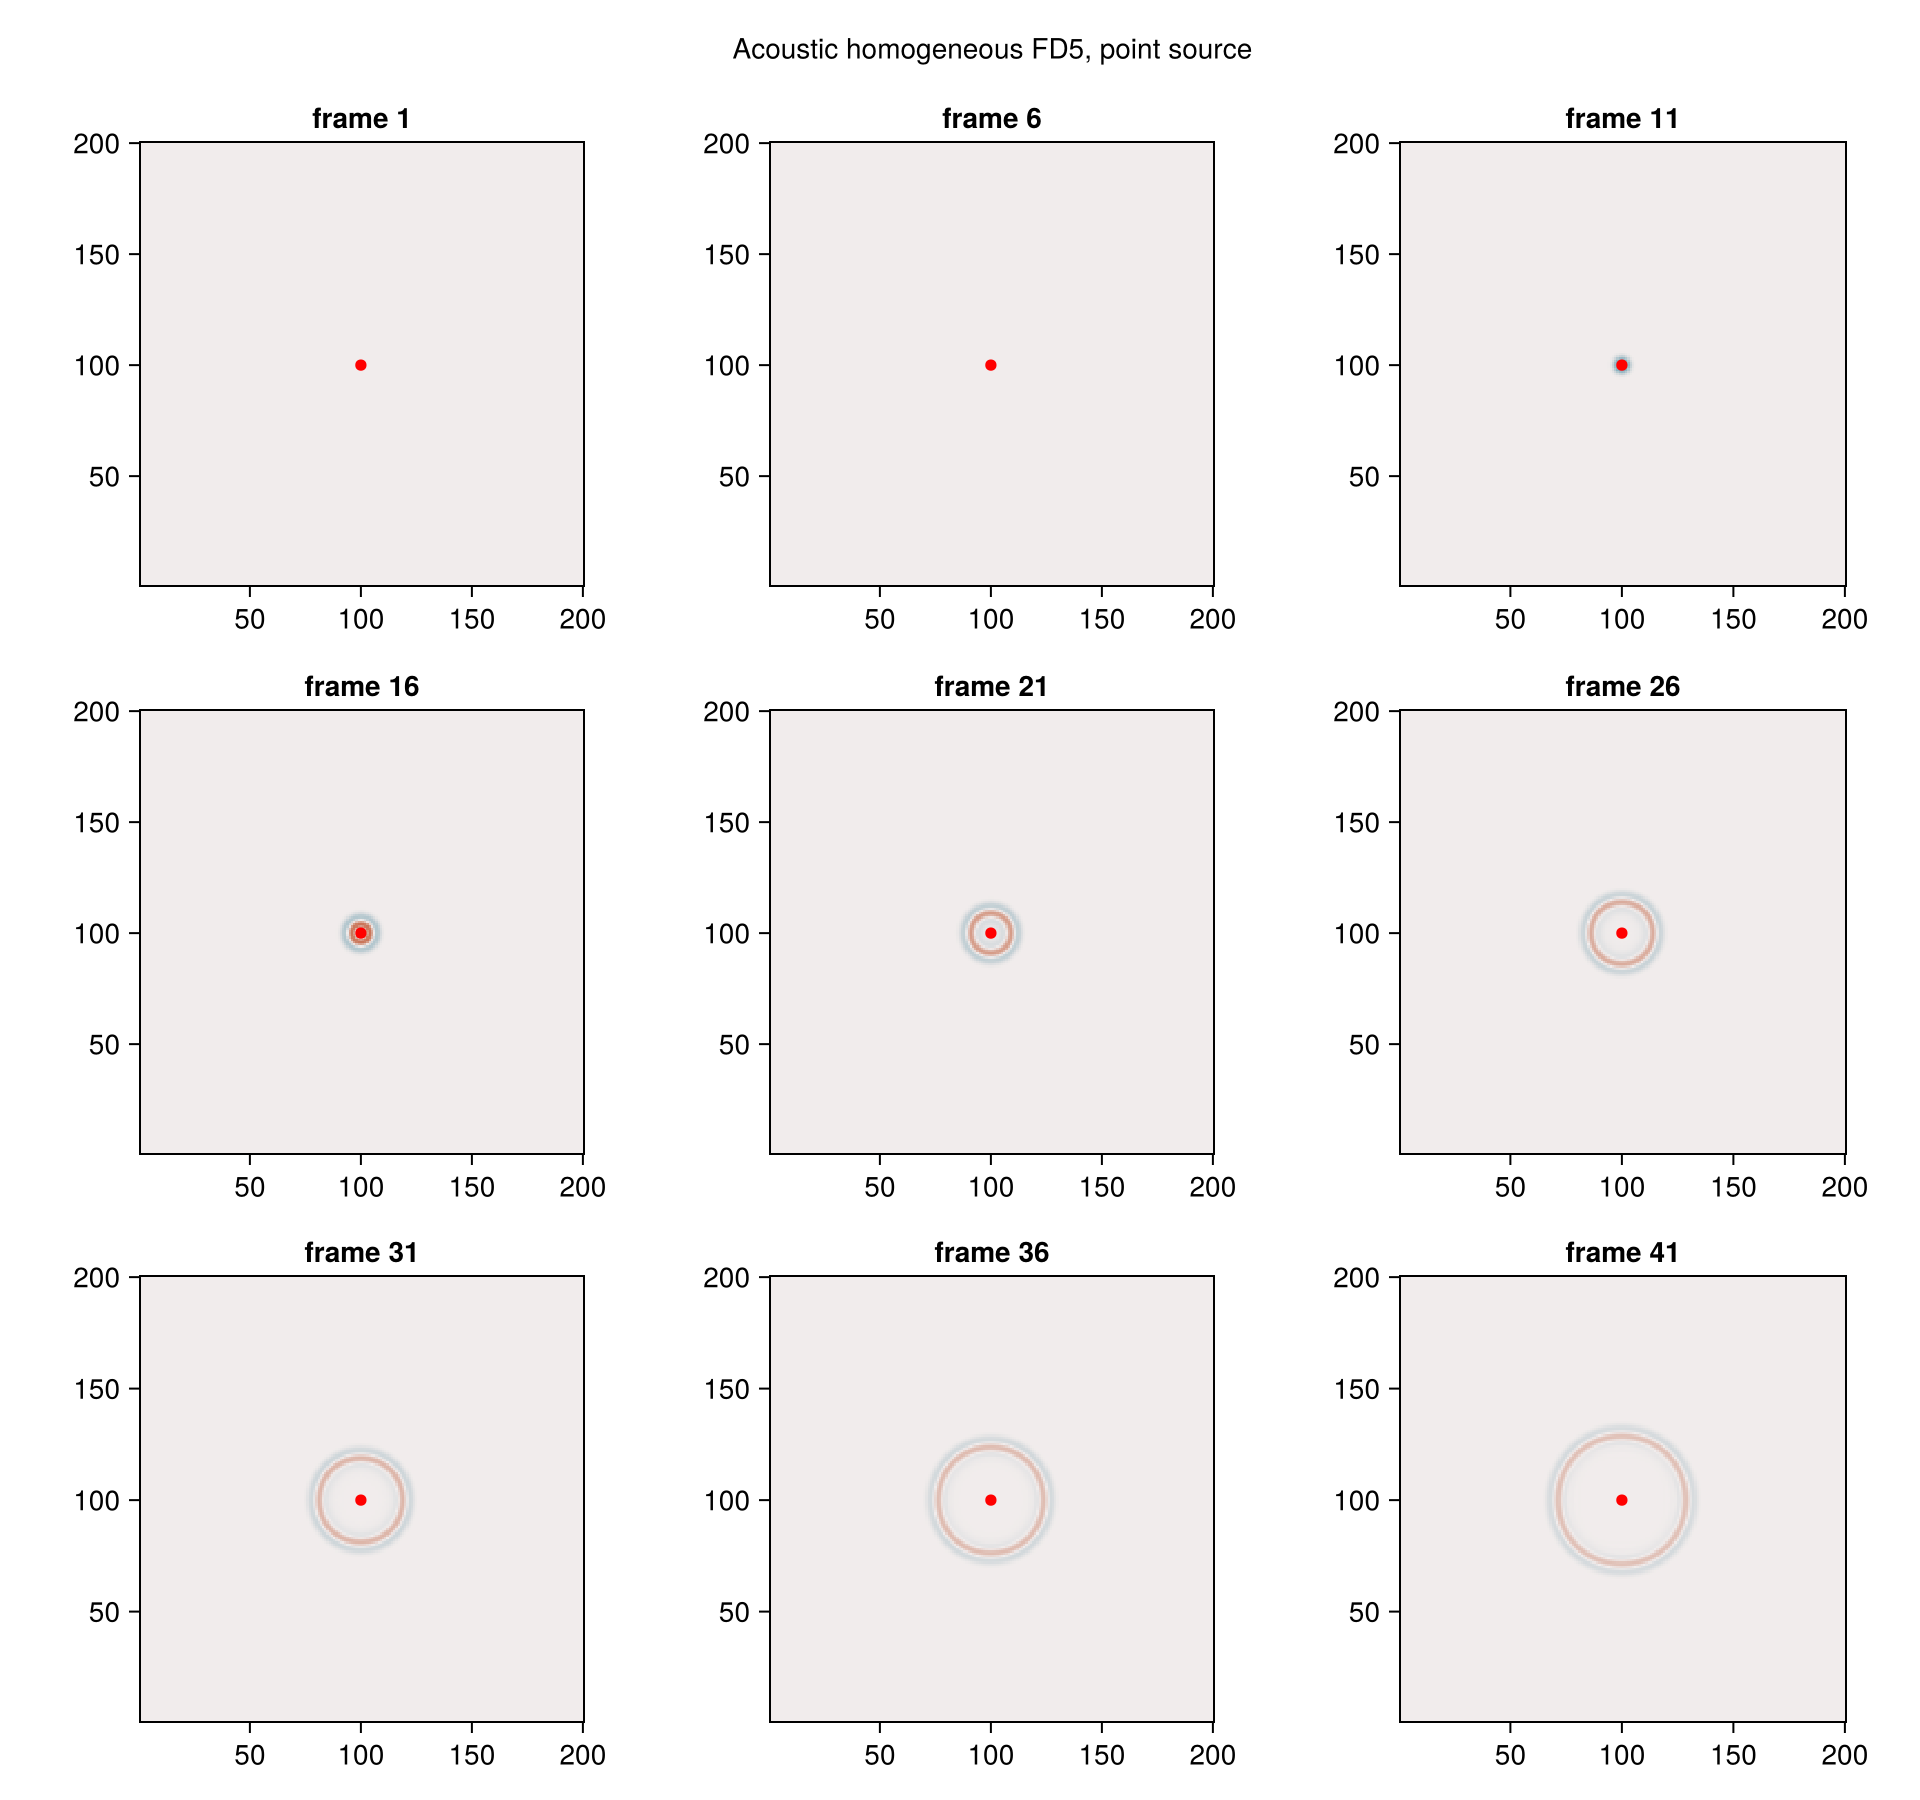

In [4]:
fig_fd5_ac = plot_wave_snapshots(
    frames_fd5_ac;
    sourcePoint=sourcePoint,
    title="Acoustic homogeneous FD5, point source",
)
fig_fd5_ac


## 4. Acoustic: OPT Source Benchmark

In [5]:
# Acoustic OPT in physical small-delta coordinates.
# If constructAmatrix becomes ill-scaled again, switch to velocity_cfl + delta=(1,1,1), as in propagateInside_run.
opt_ac = build_opt_prepared(
    "2DacousticTime",
    [velocity_homo],
    delta_acoustic;
    pointsInSpace=3,
    pointsInTime=3,
    supplementaryOrder=2,
    orderBspace=1,
    orderBtime=1,
    YorderBspace=-1,
    YorderBtime=-1,
    modelName="homogeneous_200_acoustic_OPT",
)
preparedOPT_ac = opt_ac.prepared
st_opt_ac = operator_stencil_at_point(opt_ac.numOps, sourcePoint; which=:left)
st_rhs_ac = rhs_stencil_at_source(opt_ac.numOps, sourcePoint; iExpr=1, iForceField=1)
@show implicit_matrix_report(preparedOPT_ac)
stencil_time_summary(st_opt_ac), stencil_matrices_by_time(st_opt_ac), stencil_time_summary(st_rhs_ac), stencil_matrices_by_time(st_rhs_ac)


(vars, iVars) = (v(x, y), 1)
(vars, iVars) = (v(x, y), 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μaxes = availableμaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
μᶜaxes = availableμᶜaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
size(μPoints) = (1, 1, 1)
pointν = pointsIndices[middleLinearν] = [2, 2, 2]
(typeof(μPoints), μPoints[1], typeof(pointsIndices)) = (Array{SVector{3, Float64}, 3}, [2.0, 2.0, 2.0], Array{SVector{3, Int64}, 3})

┌ Info: File /Users/nobuaki/Documents/Github/flexOPT/data/taylorCoefInv/taylorCoefInv_c0162c3e.jld2 does not exist. Producing it now...
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_files.jl:106


typeof(pointsIndices) = Array{SVector{3, Int64}, 3}
(multiOrdersIndices, pointsIndices, μpointsIndices) = (CartesianIndices((5, 5, 5)), SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]], SVector{3, Float64}[[2.0, 2.0, 2.0];;;])


┌ Warning: The Git repository ('/Users/nobuaki/Documents/Github/flexOPT') is dirty! Appending -dirty to the commit ID.
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_tools.jl:71
┌ Info: File /Users/nobuaki/Documents/Github/flexOPT/data/taylorCoefInv/taylorCoefInv_c0162c3e.jld2 saved.
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_files.jl:115


nTotalSmallα = sum((length(bigα[iExpr, iField]) for iField = 1:NtypeofFields, iExpr = 1:NtypeofExpr)) = 3
all_sizes = collect.(size.(coefWYYKK)) = [[5, 5, 1, 1, 1], [5, 5, 1, 1, 1], [5, 5, 1, 1, 1]]
typeof(output_gpu) = Array{Float64, 4}
"GPU computation of Ajiννᶜ: done" = "GPU computation of Ajiννᶜ: done"
nodeValue = eachα.node = -(v(x, y)^2)
nodeValue = eachα.node = -(v(x, y)^2)
nodeValue = eachα.node = 1
(vars, iVars) = (f(x, y, t), 1)
(vars, iVars) = (f(x, y, t), 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints 

(NamedTuple[(time_slot = 1, time_role = :past_2, n = 9, sumcoef = 525279.3231706175, sumabs = 525279.3231706175, maxabs = 410221.2647603755), (time_slot = 2, time_role = :present, n = 9, sumcoef = -1.050558646337374e6, sumabs = 1.050558646337374e6, maxabs = 691749.0953436036), (time_slot = 3, time_role = :future, n = 9, sumcoef = 525279.3231684958, sumabs = 525279.3231684958, maxabs = 410221.2647584558)], NamedTuple[(time_slot = 1, time_role = :past_2, matrix = [8.483000529180559e-7 28764.51460183768 8.483000529140395e-7; 28764.51460219648 410221.2647603755 28764.51460129944; 8.482975062793103e-7 28764.51460151516 8.483000528986978e-7]), (time_slot = 2, time_role = :present, matrix = [-2.645431057529931e-6 -89702.38774587425 -2.645431057476658e-6; -89702.38774637843 -691749.0953436036 -89702.38774529356; -2.6454310575246607e-6 -89702.38774564253 -2.6454310574946008e-6]), (time_slot = 3, time_role = :future, matrix = [8.483000530519829e-7 28764.514601700925 8.483000529786671e-7; 28764.5

In [6]:
timeSignal_ac_opt = source_time_samples(Nt, dt_acoustic, preparedOPT_ac.timePointsUsedForOneStep; t0=source_t0_acoustic, f0=source_f0_acoustic)
sourceOPT_ac = point_source_full(preparedOPT_ac, sourcePoint, timeSignal_ac_opt; amplitude=source_amplitude_acoustic)
source_rhs_scan_ac = source_rhs_scan(preparedOPT_ac, sourceOPT_ac; its=1:min(12, Nt))
source_rhs_peak_ac = source_rhs_diagnostics(preparedOPT_ac, sourceOPT_ac; it=min(argmax(abs.(timeSignal_ac_opt)), Nt))
@show maximum(abs, sourceOPT_ac) source_rhs_scan_ac
@show source_rhs_peak_ac.b_max source_rhs_peak_ac.b_norm source_rhs_peak_ac.b_argmax

t_opt_ac = @elapsed frames_opt_ac_full = propagate_linear_frames_with_source(
    preparedOPT_ac,
    Nt;
    sourceFull=sourceOPT_ac,
    store_every=store_every,
    blowup_limit=1e12,
)
frames_opt_ac = component_frames(frames_opt_ac_full, 1)
report_opt_ac = wavefield_snapshot_report(frames_opt_ac)
drift_opt_ac = drift_report(frames_opt_ac, sourcePoint)
@show t_opt_ac length(frames_opt_ac) report_opt_ac[1] report_opt_ac[end] drift_opt_ac[end]


maximum(abs, sourceOPT_ac) = 1.0
source_rhs_scan_ac = NamedTuple[(it = 1, force_max = 3.1341314065699666e-5, force_nonzero = 3, b_norm = 0.0001514375266122188, b_max = 0.00014971399148915458, b_sum = -0.00019527911933238327, b_nonzero = 9, b_argmax = CartesianIndex(100, 100)), (it = 2, force_max = 6.0215375701260594e-5, force_nonzero = 3, b_norm = 0.0002964655929404972, b_max = 0.00029309146980441736, b_sum = -0.0003822932214814832, b_nonzero = 9, b_argmax = CartesianIndex(100, 100)), (it = 3, force_max = 0.0001133391387272627, force_nonzero = 3, b_norm = 0.0005686684942251705, b_max = 0.0005621963855932932, b_sum = -0.0007332996333776832, b_nonzero = 9, b_argmax = CartesianIndex(100, 100)), (it = 4, force_max = 0.00020897267446388392, force_nonzero = 3, b_norm = 0.0010686777204225867, b_max = 0.0010565149254563107, b_sum = -0.0013780629462381993, b_nonzero = 9, b_argmax = CartesianIndex(100, 100)), (it = 5, force_max = 0.0003773865064731328, force_nonzero = 3, b_norm = 0.0019673954714

(frame = 41, cm_x = 99.99999999715443, cm_z = 99.9999999962438, drift_x = -2.845567337317334e-9, drift_z = -3.7561989074674784e-9, maxabs = 1.5431542696026164e-5)

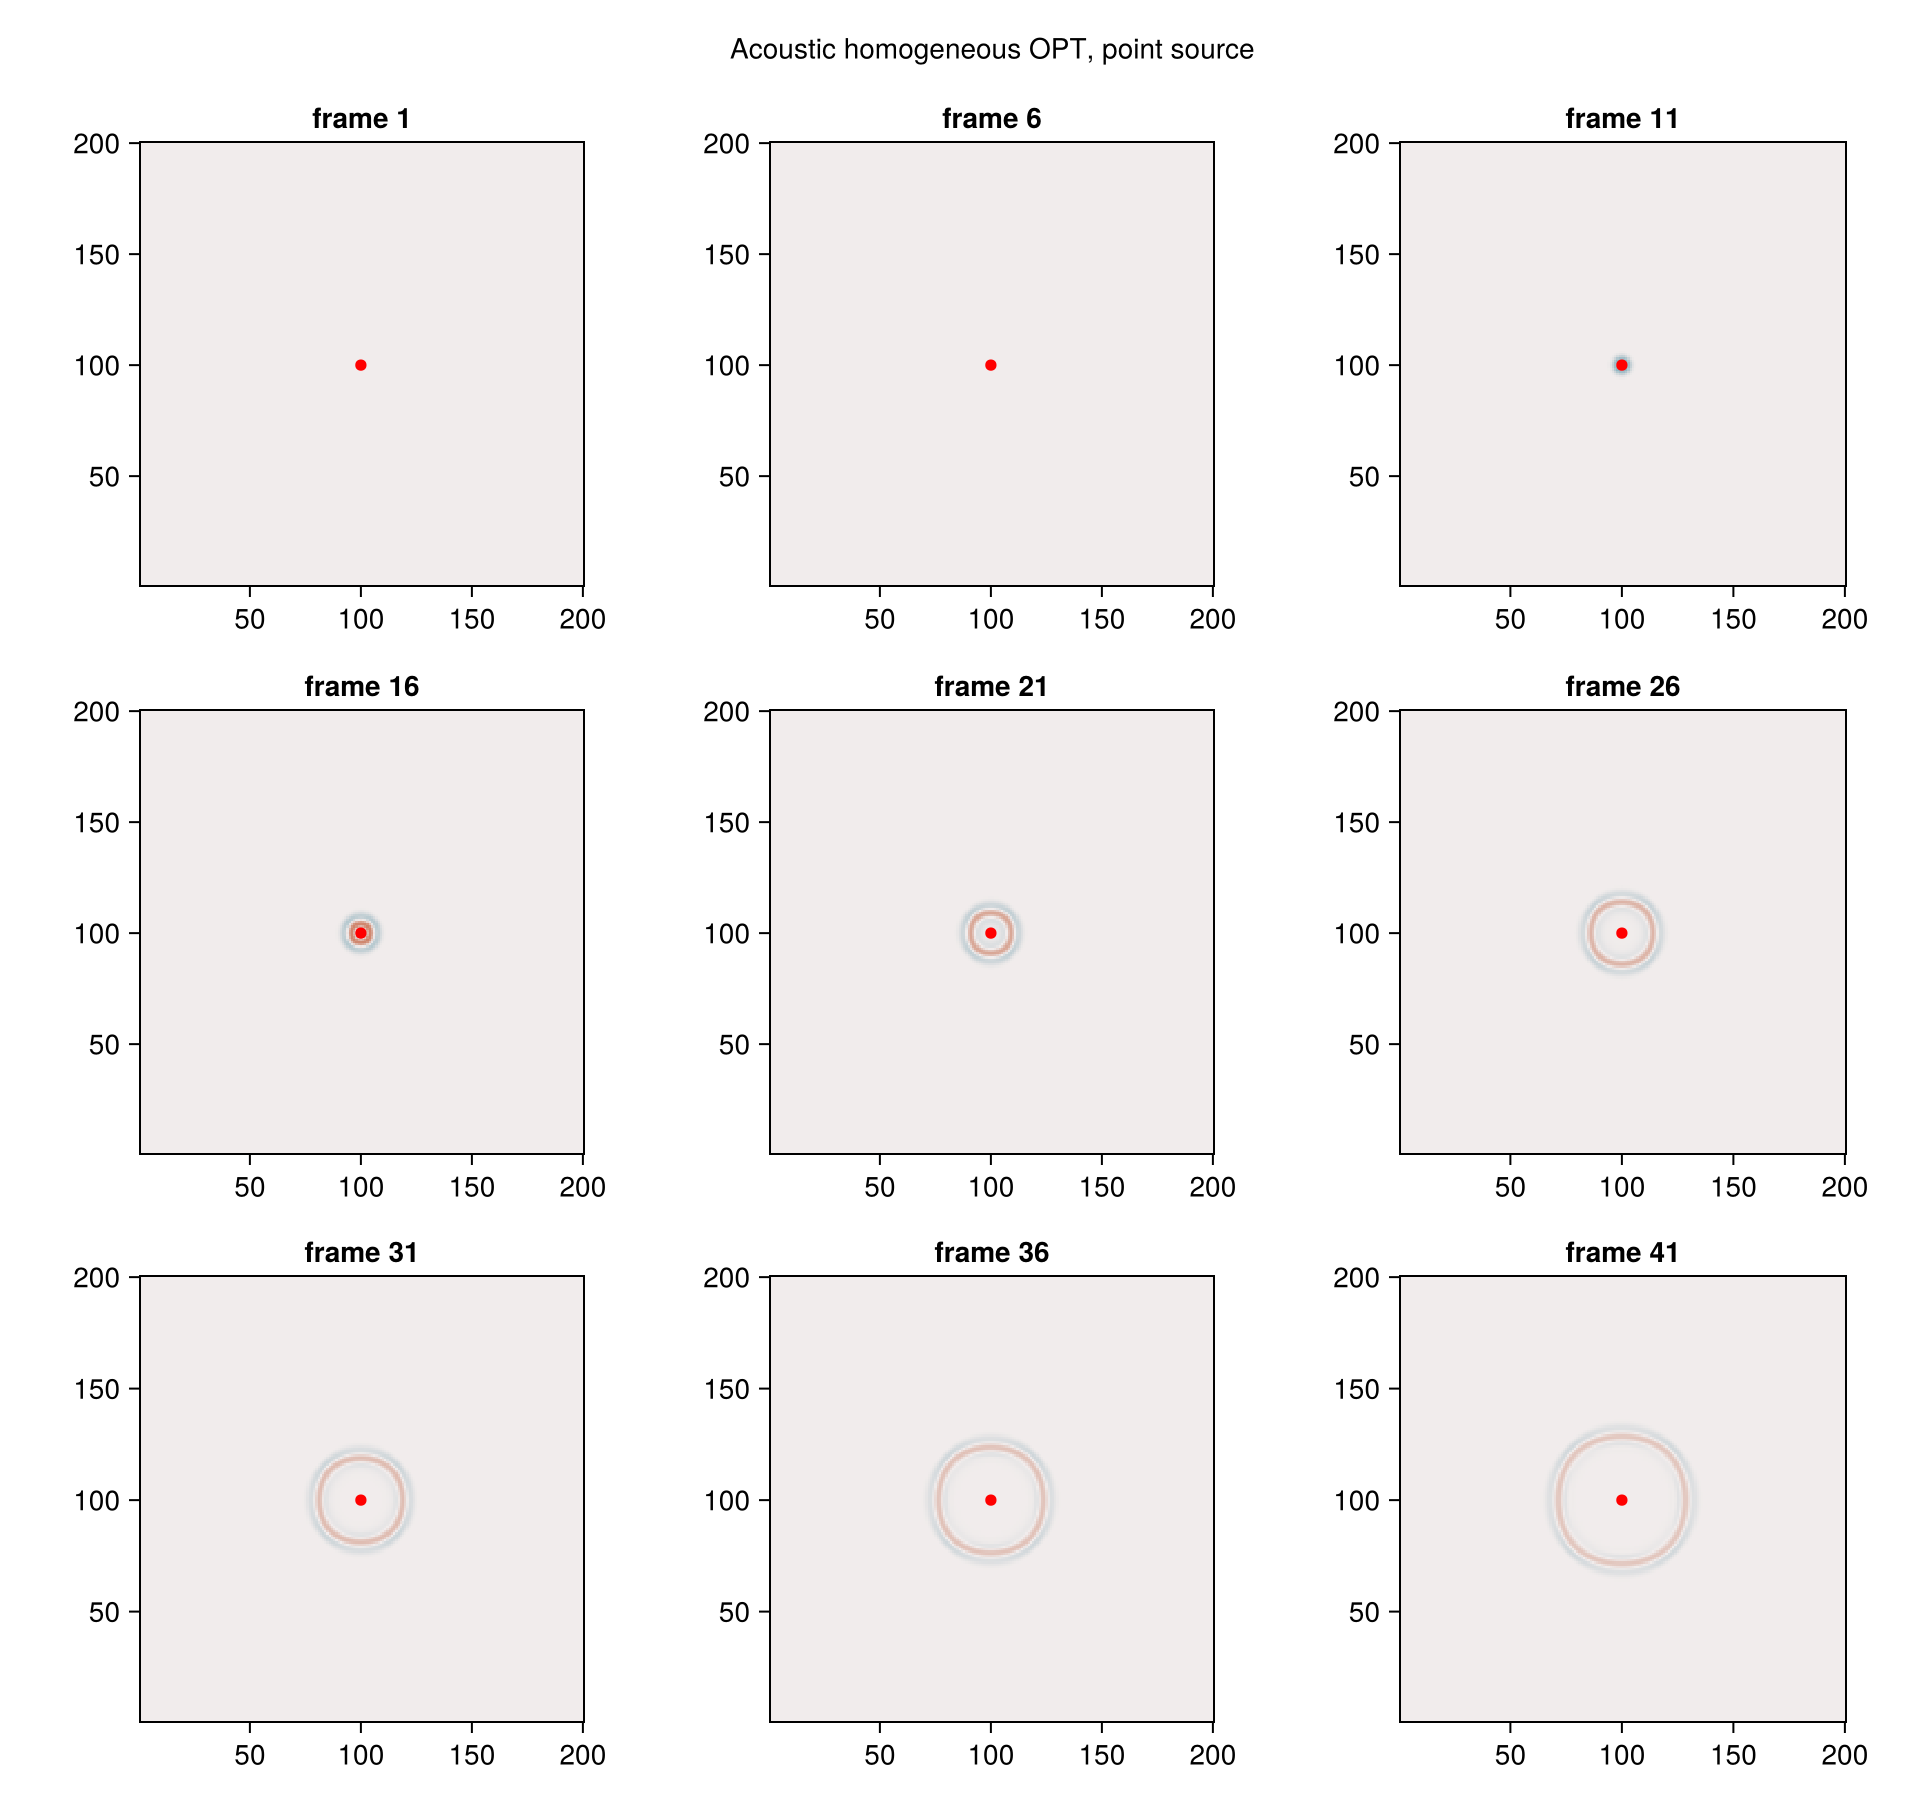

In [7]:
fig_opt_ac = plot_wave_snapshots(
    frames_opt_ac;
    sourcePoint=sourcePoint,
    title="Acoustic homogeneous OPT, point source",
)
fig_opt_ac


## 5. Acoustic LHS Benchmark From Gaussian Initial Field

This avoids source differences and compares only propagation from the same initial condition.

In [8]:
initial_ac = gaussian_field(shape, sourcePoint; sigma=8.0, amplitude=1.0)
zero_ac = zeros(Float64, shape)

t_fd5_gauss_ac = @elapsed frames_fd5_gauss_ac_full = propagate_linear_frames_with_source(
    preparedFD5_ac,
    Nt;
    initialPast=initial_ac,
    initialPresent=initial_ac,
    store_every=store_every,
    blowup_limit=1e12,
)
t_opt_gauss_ac = @elapsed frames_opt_gauss_ac_full = propagate_linear_frames_with_source(
    preparedOPT_ac,
    Nt;
    initialPast=initial_ac,
    initialPresent=initial_ac,
    store_every=store_every,
    blowup_limit=1e12,
)
frames_fd5_gauss_ac = component_frames(frames_fd5_gauss_ac_full, 1)
frames_opt_gauss_ac = component_frames(frames_opt_gauss_ac_full, 1)
diff_gauss_ac = frame_difference_report(frames_opt_gauss_ac, frames_fd5_gauss_ac)
@show t_fd5_gauss_ac t_opt_gauss_ac diff_gauss_ac[end]


ErrorException: initialPast should have size (200, 200, 1)

In [9]:
fig_gauss_ac = Figure(size=(1100, 450))
idx = length(frames_fd5_gauss_ac)
clim = maximum(abs, frames_fd5_gauss_ac[idx])
ax1 = Axis(fig_gauss_ac[1, 1], aspect=DataAspect(), title="FD5 acoustic Gaussian")
heatmap!(ax1, frames_fd5_gauss_ac[idx]; colormap=:balance, colorrange=(-clim, clim))
ax2 = Axis(fig_gauss_ac[1, 2], aspect=DataAspect(), title="OPT acoustic Gaussian")
heatmap!(ax2, frames_opt_gauss_ac[idx]; colormap=:balance, colorrange=(-clim, clim))
fig_gauss_ac


UndefVarError: UndefVarError: `frames_fd5_gauss_ac` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## 6. Elastic Homogeneous: FD Baseline And OPT

FD here is a homogeneous collocated displacement baseline with body-force RHS. The clean comparison below uses Gaussian initial displacement, not source injection.

In [10]:
rho0 = 2500.0
vp0 = 3200.0
vs0 = 1800.0
rho_el = fill(rho0, shape)
vp_el = fill(vp0, shape)
vs_el = fill(vs0, shape)
mu_el = rho_el .* vs_el.^2
lambda_el = rho_el .* vp_el.^2 .- 2 .* mu_el
models_el = [rho_el, lambda_el, mu_el]

cfl_elastic = 0.25
dt_elastic = cfl_elastic * dx / (sqrt(2) * vp0)
delta_elastic = (dx, dx, dt_elastic)
Nt_elastic = 120
store_every_elastic = 4
@show delta_elastic Nt_elastic extrema(lambda_el) extrema(mu_el)

preparedFD_el = prepare_fd2d_elastic_homogeneous_baseline(rho_el, lambda_el, mu_el, delta_elastic)
opt_el = build_opt_prepared(
    "2DsismoTimeIsoHetero",
    models_el,
    delta_elastic;
    pointsInSpace=3,
    pointsInTime=3,
    supplementaryOrder=2,
    orderBspace=1,
    orderBtime=1,
    YorderBspace=-1,
    YorderBtime=-1,
    modelName="homogeneous_200_elastic_OPT",
)
preparedOPT_el = opt_el.prepared
@show implicit_matrix_report(preparedFD_el)
@show implicit_matrix_report(preparedOPT_el)


delta_elastic = (50.0, 50.0, 0.002762135864009951)
Nt_elastic = 120
extrema(lambda_el) = (9.4e9, 9.4e9)
extrema(mu_el) = (8.1e9, 8.1e9)
(vars, iVars) = ((ρ(x, y), λ(x, y), μ(x, y)), 1)
(vars, iVars) = ((ρ(x, y), λ(x, y), μ(x, y)), 2)
(vars, iVars) = ((ρ(x, y), λ(x, y), μ(x, y)), 3)
(vars, iVars) = ((ρ(x, y), λ(x, y), μ(x, y)), 1)
(vars, iVars) = ((ρ(x, y), λ(x, y), μ(x, y)), 2)
(vars, iVars) = ((ρ(x, y), λ(x, y), μ(x, y)), 3)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVecto

┌ Info: File /Users/nobuaki/Documents/Github/flexOPT/data/taylorCoefInv/taylorCoefInv_9996bb81.jld2 does not exist. Producing it now...
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_files.jl:106
┌ Warning: The Git repository ('/Users/nobuaki/Documents/Github/flexOPT') is dirty! Appending -dirty to the commit ID.
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_tools.jl:71
┌ Info: File /Users/nobuaki/Documents/Github/flexOPT/data/taylorCoefInv/taylorCoefInv_9996bb81.jld2 saved.
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_files.jl:115


[[5, 5, 1, 1, 1], [5, 5, 1, 1, 1], [5, 5, 1, 1, 1]]
typeof(output_gpu) = Array{Float64, 4}
"GPU computation of Ajiννᶜ: done" = "GPU computation of Ajiννᶜ: done"
nodeValue = eachα.node = -λ(x, y)
nodeValue = eachα.node = -2μ(x, y)
nodeValue = eachα.node = -λ(x, y)
nodeValue = eachα.node = -2μ(x, y)
nodeValue = eachα.node = -μ(x, y)
nodeValue = eachα.node = -μ(x, y)
nodeValue = eachα.node = ρ(x, y)
nodeValue = eachα.node = -μ(x, y)
nodeValue = eachα.node = -λ(x, y)
nodeValue = eachα.node = -μ(x, y)
nodeValue = eachα.node = -λ(x, y)
nodeValue = eachα.node = -μ(x, y)
nodeValue = eachα.node = -λ(x, y)
nodeValue = eachα.node = -μ(x, y)
nodeValue = eachα.node = -μ(x, y)
nodeValue = eachα.node = -λ(x, y)
nodeValue = eachα.node = -2μ(x, y)
nodeValue = eachα.node = -λ(x, y)
nodeValue = eachα.node = -2μ(x, y)
nodeValue = eachα.node = ρ(x, y)
(vars, iVars) = (((M(x, y, t))[1, 1], (M(x, y, t))[1, 2], (M(x, y, t))[2, 1], (M(x, y, t))[2, 2]), 1)
(vars, iVars) = (((M(x, y, t))[1, 1], (M(x, y, t))[1, 2

(size = (80000, 80000), nnz = 1430416, stored_finite = 1430416, stored_nonfinite = 0, stored_nan = 0, stored_inf = 0, zero_rows_finite = 0, rows_with_nonfinite = 0, finite_abs_min = 4.288463059586279e-17, finite_abs_median = 6306.076440436823, finite_abs_max = 5.620650392786748e15, diag_finite_count = 80000, diag_nonfinite_count = 0, diag_abs_min = 0.0, diag_abs_median = 0.0, diag_abs_max = 5.620650392786748e15, finite_row_abs_min = 6.475966750057892e15, finite_row_abs_max = 7.331283107363204e15)

In [11]:
initial_ux = gaussian_field(shape, sourcePoint; sigma=10.0, amplitude=1.0)
initial_uz = zeros(Float64, shape)
initial_el = zeros(Float64, shape..., 2)
initial_el[:, :, 1] .= initial_ux
initial_el[:, :, 2] .= initial_uz

t_fd_el = @elapsed frames_fd_el_full = propagate_linear_frames_with_source(
    preparedFD_el,
    Nt_elastic;
    initialPast=initial_el,
    initialPresent=initial_el,
    store_every=store_every_elastic,
    blowup_limit=1e12,
)
t_opt_el = @elapsed frames_opt_el_full = propagate_linear_frames_with_source(
    preparedOPT_el,
    Nt_elastic;
    initialPast=initial_el,
    initialPresent=initial_el,
    store_every=store_every_elastic,
    blowup_limit=1e12,
)

ux_fd_el = component_frames(frames_fd_el_full, 1)
uz_fd_el = component_frames(frames_fd_el_full, 2)
ux_opt_el = component_frames(frames_opt_el_full, 1)
uz_opt_el = component_frames(frames_opt_el_full, 2)
diff_ux_el = frame_difference_report(ux_opt_el, ux_fd_el)
diff_uz_el = frame_difference_report(uz_opt_el, uz_fd_el)
@show t_fd_el t_opt_el
@show wavefield_snapshot_report(ux_fd_el)[end] wavefield_snapshot_report(ux_opt_el)[end]
@show diff_ux_el[end] diff_uz_el[end]


t_fd_el = 1.325888
t_opt_el = 4.728392208
(wavefield_snapshot_report(ux_fd_el))[end] = (frame = 31, nbad = 0, finite_max = 0.3157644123627835, minimum = -0.09851150441843828, maximum = 0.3157644123627835)
(wavefield_snapshot_report(ux_opt_el))[end] = (frame = 31, nbad = 0, finite_max = 0.9999990781290732, minimum = 3.720273492399613e-44, maximum = 0.9999990781290732)
diff_ux_el[end] = (frame = 31, max_a = 0.9999990781290732, max_b = 0.3157644123627835, maxdiff = 1.0985105825475114, reldiff = 1.098511595233414)
diff_uz_el[end] = (frame = 31, max_a = 7.822279710412018e-18, max_b = 0.12146025241467752, maxdiff = 0.12146025241467752, reldiff = 1.0)


(frame = 31, max_a = 7.822279710412018e-18, max_b = 0.12146025241467752, maxdiff = 0.12146025241467752, reldiff = 1.0)

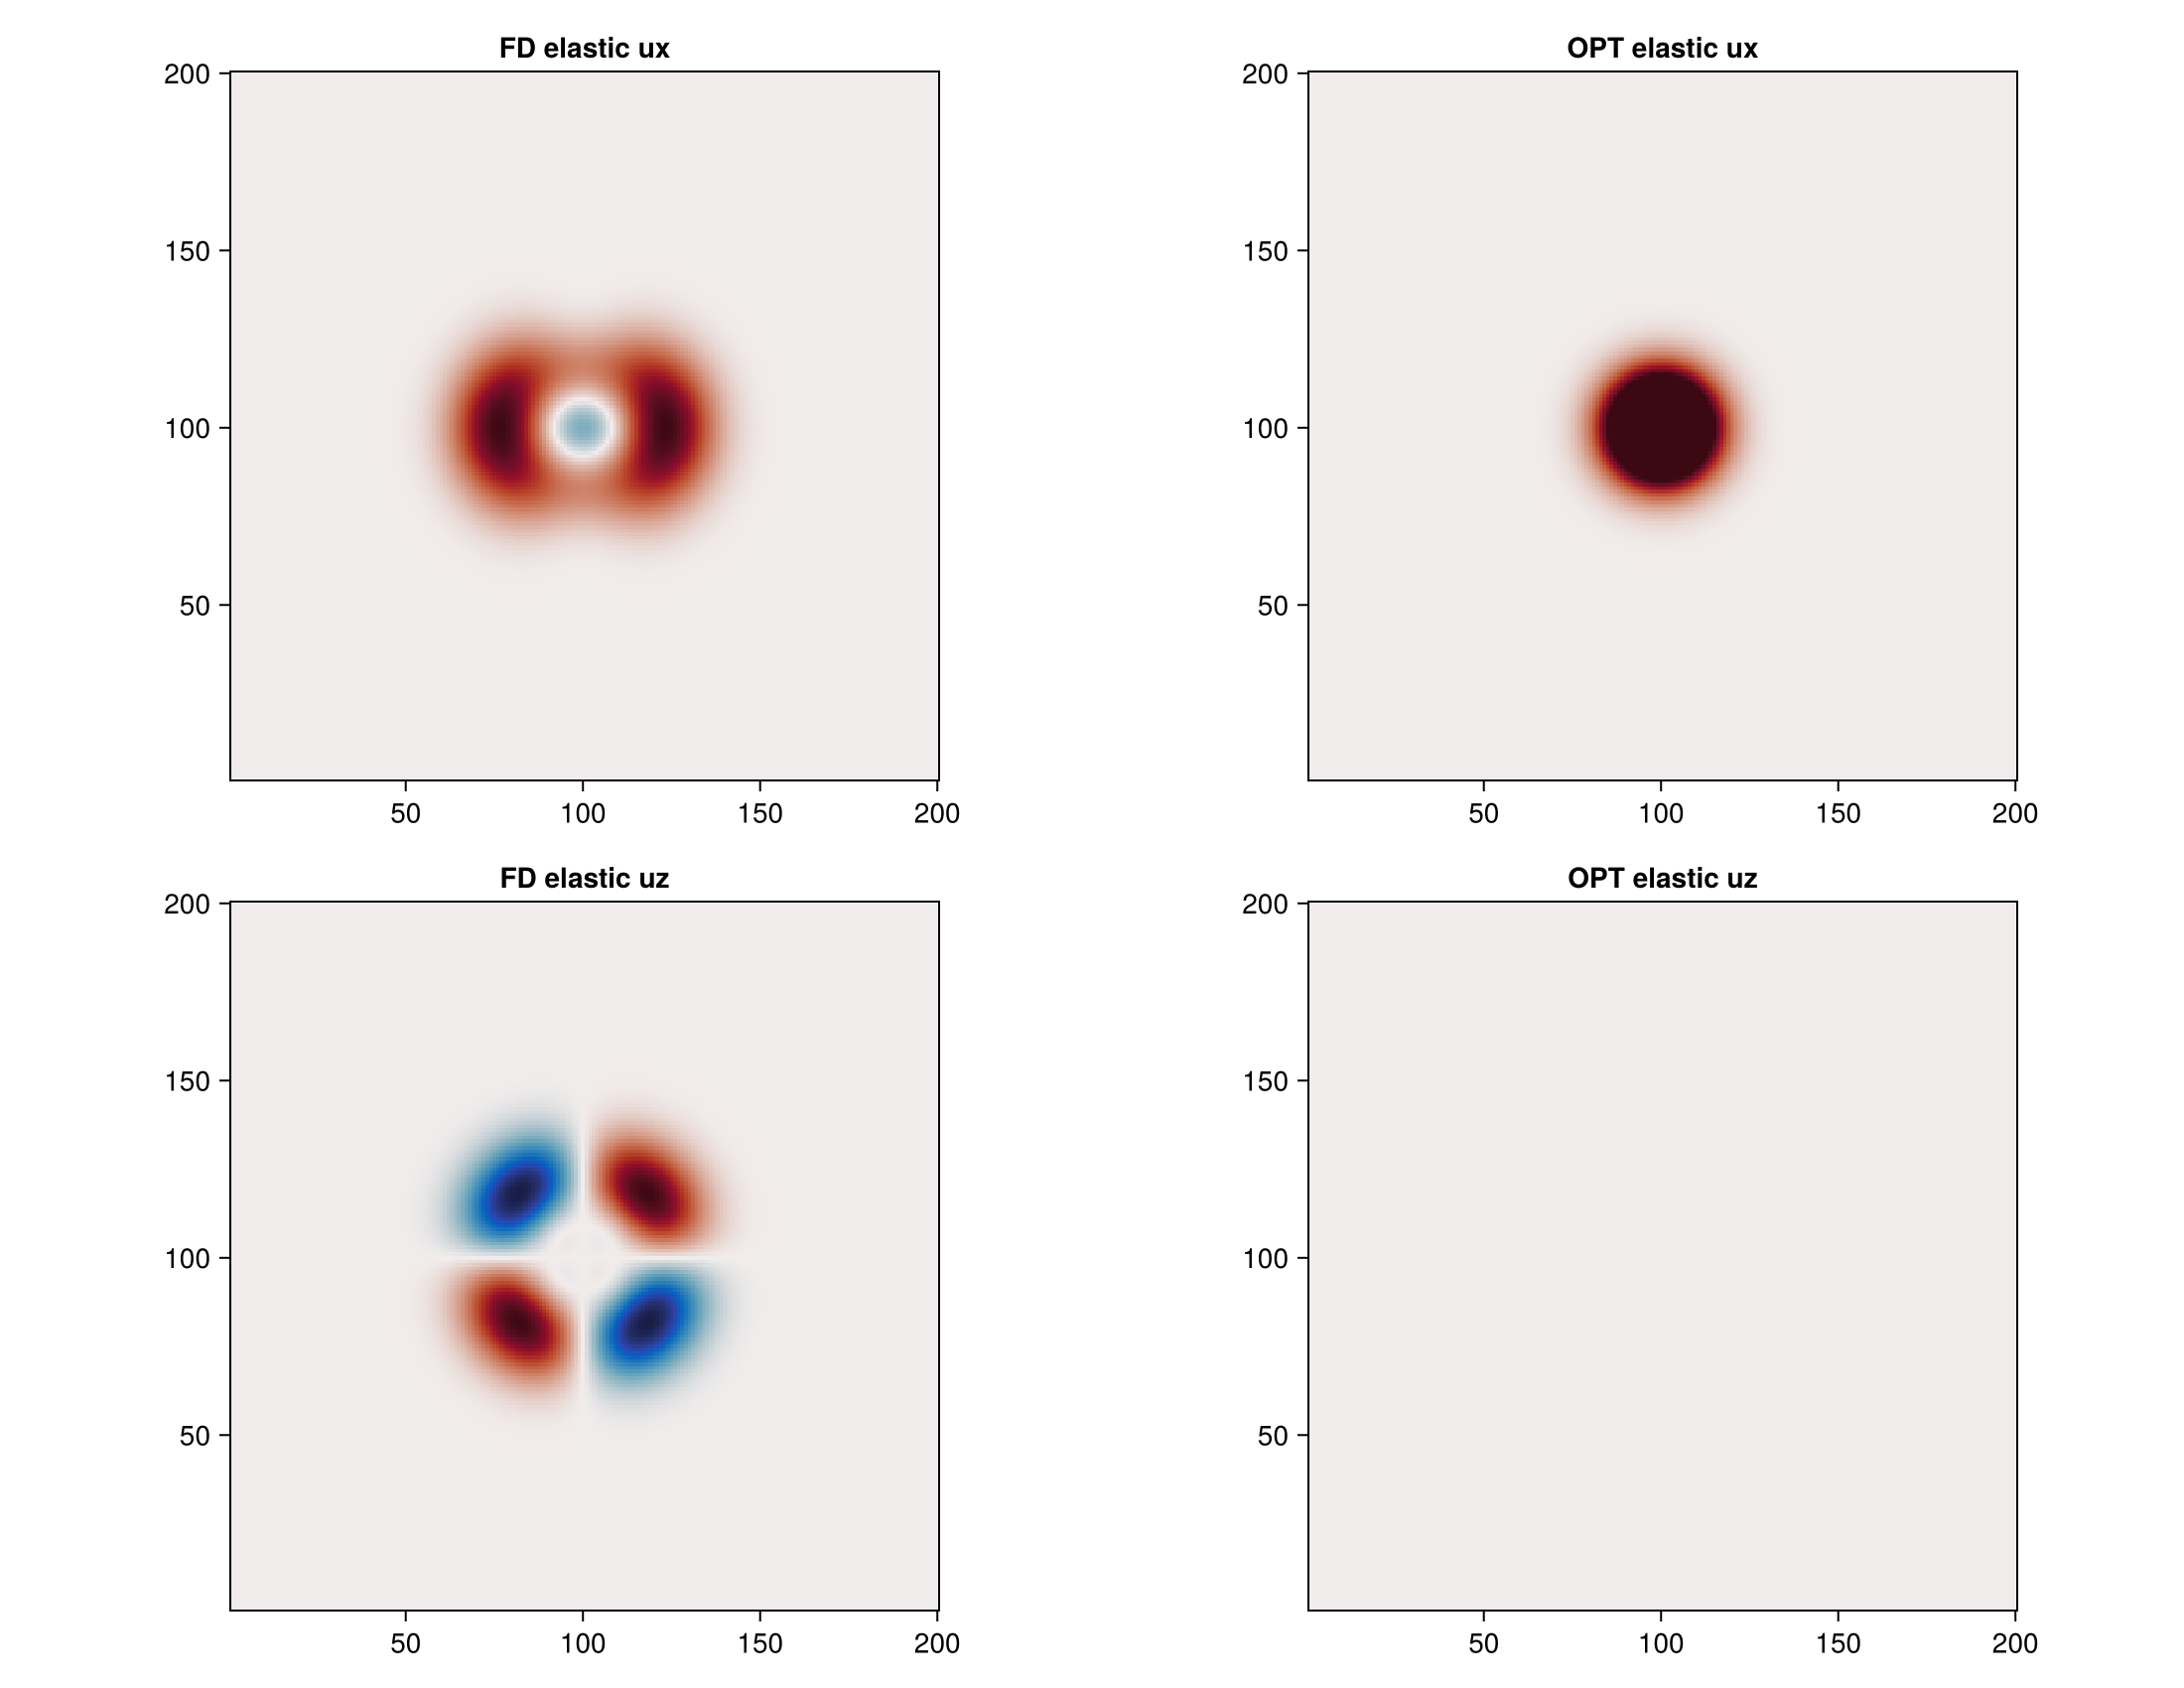

In [12]:
fig_el = Figure(size=(1100, 850))
idx = length(ux_fd_el)
clim_ux = maximum(abs, ux_fd_el[idx])
clim_uz = max(maximum(abs, uz_fd_el[idx]), maximum(abs, uz_opt_el[idx]), eps(Float64))
ax11 = Axis(fig_el[1, 1], aspect=DataAspect(), title="FD elastic ux")
heatmap!(ax11, ux_fd_el[idx]; colormap=:balance, colorrange=(-clim_ux, clim_ux))
ax12 = Axis(fig_el[1, 2], aspect=DataAspect(), title="OPT elastic ux")
heatmap!(ax12, ux_opt_el[idx]; colormap=:balance, colorrange=(-clim_ux, clim_ux))
ax21 = Axis(fig_el[2, 1], aspect=DataAspect(), title="FD elastic uz")
heatmap!(ax21, uz_fd_el[idx]; colormap=:balance, colorrange=(-clim_uz, clim_uz))
ax22 = Axis(fig_el[2, 2], aspect=DataAspect(), title="OPT elastic uz")
heatmap!(ax22, uz_opt_el[idx]; colormap=:balance, colorrange=(-clim_uz, clim_uz))
fig_el


## 7. Marmousi Small-Delta Sketch

This section is intentionally a template: resample/crop Marmousi to a smaller `dx` if the data resolution permits it. The acoustic check above suggests that trusting wavefields at smaller `δ` is the right direction.

In [13]:
# marmousi = load(joinpath(@__DIR__, "tmp/seismicModelMarmousi.jld2"), "output")
# shape_m = (200, 200)
# downsample_step_m = 1
# velocity_m = downsample_center_crop(marmousi.Vpv .* 1e3, shape_m; step=downsample_step_m)
# dx_m = 100.0 # set to the true data spacing if known
# cfl_m = 0.35
# dt_m = cfl_m * dx_m / (sqrt(2) * maximum(velocity_m))
# delta_m = (dx_m, dx_m, dt_m)
# preparedFD5_m = prepare_fd2d_acoustic_fd5_baseline(velocity_m, delta_m)
# opt_m = build_opt_prepared("2DacousticTime", [velocity_m], delta_m; pointsInSpace=3, pointsInTime=3, supplementaryOrder=2, YorderBspace=-1, YorderBtime=-1)
